In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch
import shutil
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from sklearn.manifold import TSNE
import multiprocessing
import types
from torchvision.models.resnet import Bottleneck
from torch.utils.data import Subset
import numpy as np
import gc

RESULTS_DIR = Path("/kaggle/working/results")
RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
!rm -f file_utils.py model_utils.py

!wget -q https://raw.githubusercontent.com/TayyabWaseem/vision-representations-study/main/utils/file_utils.py -O file_utils.py
!wget -q https://raw.githubusercontent.com/TayyabWaseem/vision-representations-study/main/utils/model_utils.py -O model_utils.py

import model_utils
import file_utils

In [3]:
%config Completer.use_jedi = False

In [4]:
# plt.savefig(RESULTS_DIR / "resnet_tsne.png") ht")

# with open(RESULTS_DIR / "log.txt", "a") as f:
#     f.write(f"ResNet baseline val acc: {val_acc}\n")

# df.to_csv(RESULTS_DIR / "logs" / "clip_prompt_comparison.csv", index=False)

# shutil.make_archive("/kaggle/working/results", "zip", OUT)

## Step 0: Downloading Data

In [5]:
# -------- data --------
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

subset_size = 10000

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)

indices = np.random.choice(len(train_set), subset_size, replace=False)
# Create the smaller subset dataset
train_dataset_subset = Subset(train_set, indices)

train_loader = DataLoader(
    train_dataset_subset,
    batch_size=128,          # Increased batch size reduces step overhead
    shuffle=True,
    num_workers=2,           # Parallel data pre-processing on CPU
    pin_memory=True          # Accelerates CUDA tensor copies
)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
# test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(
    test_set,
    batch_size=256,          # Validation can use even larger batches
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 170M/170M [34:04<00:00, 83.4kB/s]


## Baseline Setup

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 224MB/s]


Epoch 1/5 - Avg Loss: 1.2656 - Val Acc: 76.21%
Epoch 2/5 - Avg Loss: 0.7179 - Val Acc: 79.12%
Epoch 3/5 - Avg Loss: 0.5859 - Val Acc: 80.96%
Epoch 4/5 - Avg Loss: 0.5239 - Val Acc: 81.25%
Epoch 5/5 - Avg Loss: 0.4757 - Val Acc: 81.92%


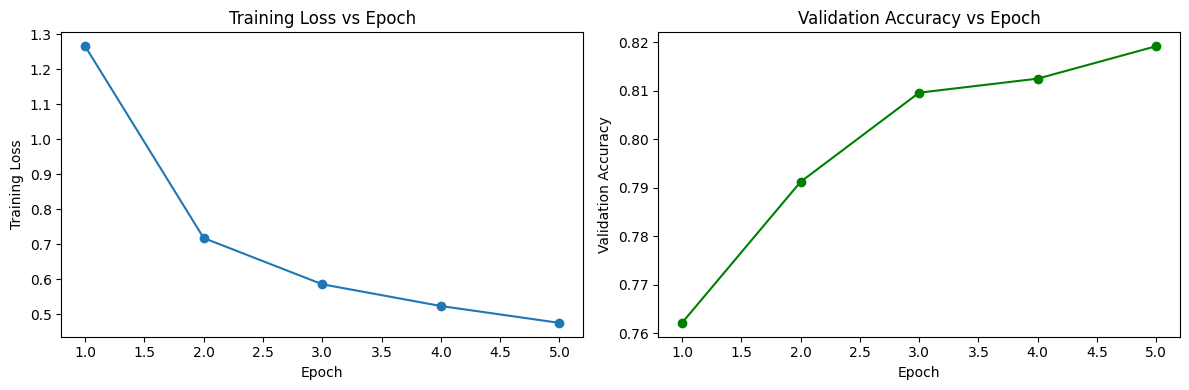

In [6]:
# (a) Use a pre-trained ResNet-152 from PyTorch.
# IMAGENET1K_V2 provides state-of-the-art pre-trained weights for this architecture
# It is the newer version

from torchvision.models import resnet152, ResNet152_Weights
model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2, progress=True)

# (b) Replace the final classification layer to match a smaller dataset such as CIFAR-10.
# If we print the model, at the end of the output we get:
# (fc): Linear(in_features=2048, out_features=1000, bias=True)
# This shows that the final fully-connected layer maps from 2048 -> 1000
# To match a CIFAR-10 dataset, it needs to map from 2048 -> 10
# fc layer -> nn.Linear() layer
# No need to hardcode 2048

model.fc = nn.Linear(model.fc.in_features, 10)

# (c) Train only the classification head while freezing the rest of the backbone.
# Freeze all model parameters first
# Then unfreeze model.fc parameters
# Then run the optimizer

for param in model.parameters():
    param.requires_grad = False
    
for param in model.fc.parameters():
    param.requires_grad = True

# for name, param in model.named_parameters():  # for testing if it worked
#     print(name, param.requires_grad)

# (d) Record training and validation performance for a few epochs.
# We should plot a graph here comparing the training and performance with epochs
# Let's go with 5 epochs for good measure
# Have to load CIFAR-10 first
# Use Adam's Optimizer due to quicker convergence
# Use CrossEntropyLoss because it's multi-class classification

# --------- optimizer and loss ---------
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
model = model.to(device)

# -------- training helper --------
def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

training_history = []
epochs = 5

# --------- training loop ---------
for epoch in range(1,epochs+1): # 5 epochs
    model.train()
    current_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        current_loss += loss.item()
        
    avg_loss = current_loss / len(train_loader)
    val_acc = evaluate(test_loader)
    print(f"Epoch {epoch}/{epochs} - Avg Loss: {avg_loss:.4f} - Val Acc: {val_acc*100:.2f}%")
    training_history.append((epoch, avg_loss, val_acc))

# -------- diagrams --------
epochs_list = [h[0] for h in training_history]
loss_list   = [h[1] for h in training_history]
val_acc_list = [h[2] for h in training_history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs_list, loss_list, marker='o')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss vs Epoch")

# Validation accuracy curve
axes[1].plot(epochs_list, val_acc_list, marker='o', color='green')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy vs Epoch")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_baseline_train_val_curve.png", dpi=150)
plt.show()

## Residual Connections in Practice

Modified blocks: [Bottleneck(
  (conv1): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (downsample): Sequential(
    (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
), Bottleneck(
  (conv1): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=

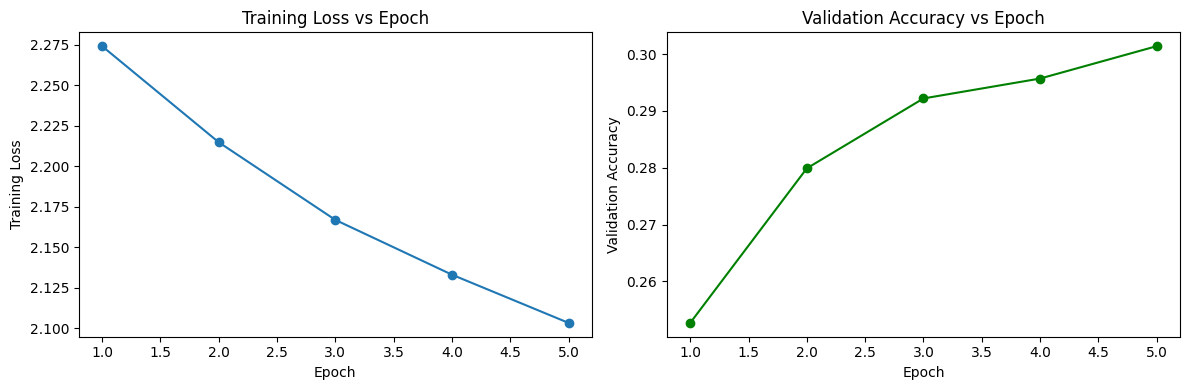

In [7]:
# (a) Disable skip connections in a few selected residual blocks and re-train the modified network head.
# Residual function: F(x) = H(x) - x ---> Output = F(x) + x
# Read documentation for the original forward pass in Bottleneck.forward()
# Write a replacement forward() pass with no skip connections

def forward_no_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    # NOTE: Skip connection removed entirely: no identity/downsample branch is computed or added
    out = self.relu(out)

    return out

# Creating a new fresh model to compare against the baseline model
# Change final layer out_features
# Then do the similar (c) freezing and unfreezing step
# Selecting a few blocks to test it on
# Create Utility functions

model_no_skip = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
model_no_skip.fc = nn.Linear(model_no_skip.fc.in_features, 10)
model_no_skip = model_utils.freeze_backbone_except(model_no_skip)

blocks_to_modify = [
    model_no_skip.layer2[0],
    model_no_skip.layer3[0],
    model_no_skip.layer4[0],
]

for block in blocks_to_modify:
    block.forward = types.MethodType(forward_no_skip, block)

model_no_skip = model_no_skip.to(device)
print("Modified blocks:", [b for b in blocks_to_modify])

# (b) Compare training dynamics and validation accuracy with the baseline

optimizer_no_skip = torch.optim.Adam(model_no_skip.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
epochs = 5

v2_training_history = model_utils.train_model(model_no_skip, train_loader, test_loader, optimizer_no_skip, criterion, device, epochs=epochs)

# -------- diagrams --------
epochs_list = [h[0] for h in v2_training_history]
loss_list   = [h[1] for h in v2_training_history]
val_acc_list = [h[2] for h in v2_training_history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs_list, loss_list, marker='o')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss vs Epoch")

# Validation accuracy curve
axes[1].plot(epochs_list, val_acc_list, marker='o', color='green')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy vs Epoch")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_no_skip_train_val_curve.png", dpi=150)
plt.show()

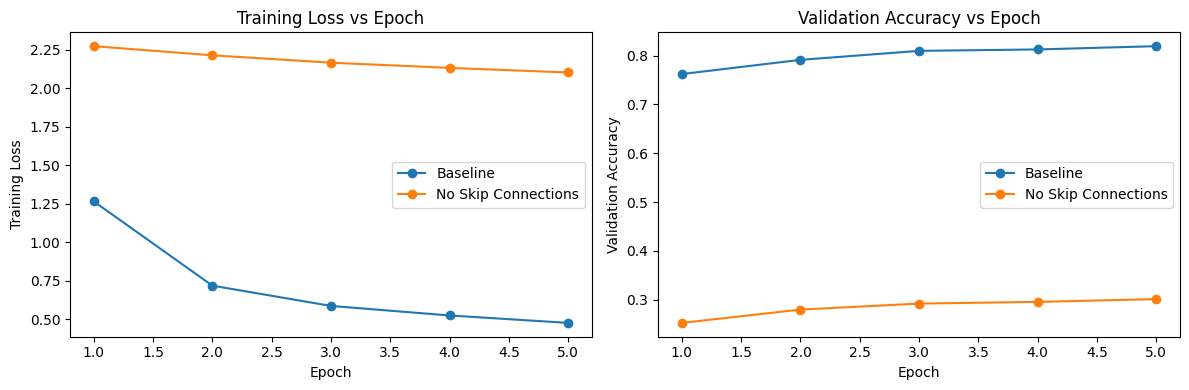

In [8]:
# -------- comparison diagrams --------
base_epochs = [h[0] for h in training_history]
base_loss   = [h[1] for h in training_history]
base_val    = [h[2] for h in training_history]

skip_epochs = [h[0] for h in v2_training_history]
skip_loss   = [h[1] for h in v2_training_history]
skip_val    = [h[2] for h in v2_training_history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(base_epochs, base_loss, marker='o', label="Baseline")
axes[0].plot(skip_epochs, skip_loss, marker='o', label="No Skip Connections")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss vs Epoch")
axes[0].legend()

axes[1].plot(base_epochs, base_val, marker='o', label="Baseline")
axes[1].plot(skip_epochs, skip_val, marker='o', label="No Skip Connections")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy vs Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_baseline_vs_no_skip.png", dpi=150)
plt.show()

## Feature Hierarchies and Representations

In [9]:
# (a) Collect features from early, middle, and late layers of the network.
# For ResNet-152, the four main stages are layer1, layer2, layer3, layer4
# Each of these outputs a 4D tensor (batch, channels, height, width)

# 1. Register forward hooks on layer1, layer3, layer4 to capture their outputs during a forward pass.
# 2. Run a batch of CIFAR-10 test images through the model once, collecting the hooked activations.
# 3. Global-average-pool each captured feature map down to a flat vector per image.
# 4. Run t-SNE (or UMAP) separately on each layer's collected features.
# 5. Plot each layer's 2D projection, colored by true class label, side by side.

activations = {}

def get_hook(name):
    def hook(module, input, output):
        # Global average pool over spatial dims -> (batch, channels)
        pooled = output.mean(dim=[2, 3]).detach().cpu()
        activations[name] = pooled
    return hook

hook_layer1 = model.layer1.register_forward_hook(get_hook("early"))
hook_layer3 = model.layer3.register_forward_hook(get_hook("middle"))
hook_layer4 = model.layer4.register_forward_hook(get_hook("late"))

# ---- Run a batch of test images through the model to trigger the hooks ----
model.eval()
all_features = {"early": [], "middle": [], "late": []}
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _ = model(images)   # forward pass triggers the hooks

        all_features["early"].append(activations["early"])
        all_features["middle"].append(activations["middle"])
        all_features["late"].append(activations["late"])
        all_labels.append(labels)

        # Only need a few hundred samples for a t-SNE plot, not the whole test set
        if len(torch.cat(all_labels)) >= 1000:
            break

hook_layer1.remove()
hook_layer3.remove()
hook_layer4.remove()

# Concatenate batches into single tensors
for key in all_features:
    all_features[key] = torch.cat(all_features[key]).numpy()
all_labels = torch.cat(all_labels).numpy()

print({k: v.shape for k, v in all_features.items()})
print(all_labels.shape)

{'early': (1024, 256), 'middle': (1024, 1024), 'late': (1024, 2048)}
(1024,)


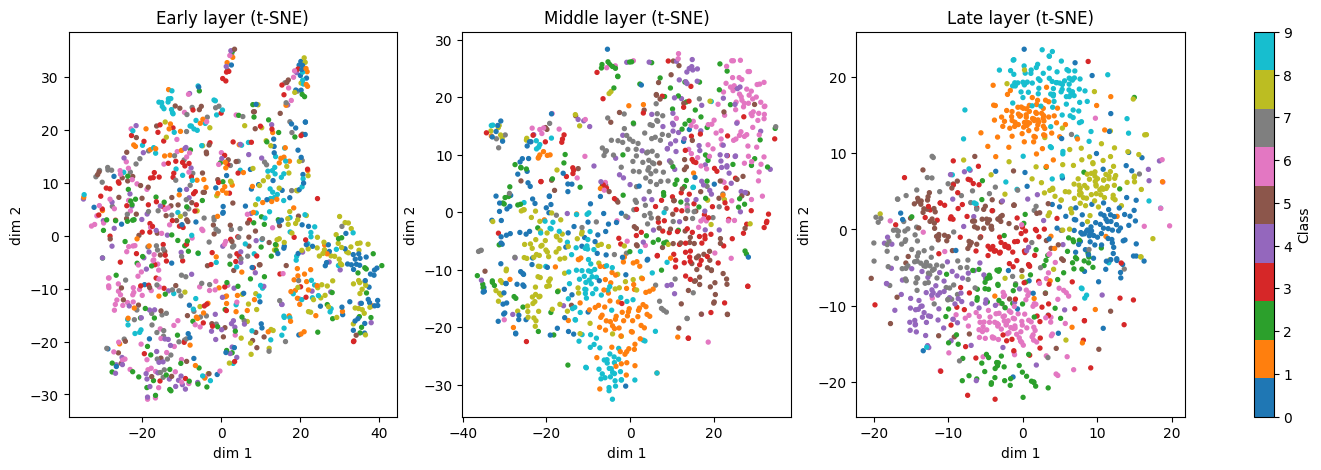

In [10]:
# (b) Visualize these features using dimensionality reduction (t-SNE or UMAP).

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, feats) in zip(axes, all_features.items()):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    projected = tsne.fit_transform(feats)

    scatter = ax.scatter(projected[:, 0], projected[:, 1], c=all_labels, cmap="tab10", s=8)
    ax.set_title(f"{name.capitalize()} layer (t-SNE)")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

plt.colorbar(scatter, ax=axes, label="Class")
plt.savefig(RESULTS_DIR / "resnet_feature_hierarchy_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## Transfer Learning and Generalization

In [11]:
from model_utils import train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
epochs = 5
lr = 0.001
criterion = nn.CrossEntropyLoss()

# (a) Fine-tune the model on a dataset different from ImageNet.
# We are training the model on CIFAR-10 so this is staisfied

# (b) Compare performance between:
#    (i) using ImageNet-pretrained weights, and
#    (ii) training from random initialization.
# (c) Experiment with fine-tuning only the final block versus the full backbone.

# --------------------------------------------------------------
# Experiment 1: Pretrained weights + final block
# --------------------------------------------------------------
print("\n--- Experiment 1: Fine-Tuning Final Block + Head Only ---")
model_partial_ft = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
model_partial_ft.fc = nn.Linear(model_partial_ft.fc.in_features, 10)

# Freeze everything first
for param in model_partial_ft.parameters():
    param.requires_grad = False

# Unfreeze layer4 (final block) and fc (classification head)
for param in model_partial_ft.layer4.parameters():
    param.requires_grad = True
for param in model_partial_ft.fc.parameters():
    param.requires_grad = True

# Pass only the trainable parameters to the optimizer!
trainable_params = [p for p in model_partial_ft.parameters() if p.requires_grad]
optimizer_partial_ft = torch.optim.Adam(trainable_params, lr=lr)

hist_partial_ft = train_model(
    model_partial_ft, train_loader, test_loader, optimizer_partial_ft, 
    criterion, device, epochs=epochs, log_prefix="[Partial FT] "
)

# Force the GPU to release memory from previous tasks
torch.cuda.empty_cache()
gc.collect()

train_loader = DataLoader(
    train_dataset_subset,
    batch_size=32,          # NOTE: REDUCED BATCH SIZE TO AVOID OOM ERROR
    shuffle=True,
    num_workers=2,           # Parallel data pre-processing on CPU
    pin_memory=True          # Accelerates CUDA tensor copies
)

# --------------------------------------------------------------
# Experiment 2: Pretrained weights + full backbone
# --------------------------------------------------------------
print("\n--- Experiment 2: Fine-Tuning Full Pre-trained Backbone ---")
model_full_ft = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
model_full_ft.fc = nn.Linear(model_full_ft.fc.in_features, 10)

# All parameters are trainable by default
optimizer_full_ft = torch.optim.Adam(model_full_ft.parameters(), lr=lr)

hist_full_ft = train_model(
    model_full_ft, train_loader, test_loader, optimizer_full_ft, 
    criterion, device, epochs=epochs, log_prefix="[Full FT] "
)


# Force the GPU to release memory from previous tasks
torch.cuda.empty_cache()
gc.collect()


# --------------------------------------------------------------
# Experiment 3: Random weights + full backbone
# --------------------------------------------------------------
print("\n--- Experiment 3: Training from Scratch (Full Backbone) ---")
model_scratch = resnet152(weights=None) # weights=None means random init
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, 10)

optimizer_scratch = torch.optim.Adam(model_scratch.parameters(), lr=lr)

hist_scratch = train_model(
    model_scratch, train_loader, test_loader, optimizer_scratch, 
    criterion, device, epochs=epochs, log_prefix="[Scratch] "
)


# Force the GPU to release memory from previous tasks
torch.cuda.empty_cache()
gc.collect()

# --------------------------------------------------------------
# Experiment 4: Random weights + final block
# --------------------------------------------------------------
print("\n--- Experiment 4: Random Weights + Final Block Only ---")
model_random_partial = resnet152(weights=None)  # Random initialization
model_random_partial.fc = nn.Linear(model_random_partial.fc.in_features, 10)

# Freeze everything first
for param in model_random_partial.parameters():
    param.requires_grad = False

# Unfreeze only layer4 and fc
for param in model_random_partial.layer4.parameters():
    param.requires_grad = True
for param in model_random_partial.fc.parameters():
    param.requires_grad = True

trainable_params_rand = [p for p in model_random_partial.parameters() if p.requires_grad]
optimizer_random_partial = torch.optim.Adam(trainable_params_rand, lr=lr)

hist_random_partial = train_model(
    model_random_partial, train_loader, test_loader, optimizer_random_partial, 
    criterion, device, epochs=epochs, log_prefix="[Rand-Partial] "
)

cuda

--- Experiment 1: Fine-Tuning Final Block + Head Only ---
[Partial FT] Epoch 1/5 - Avg Loss: 0.6006 - Val Acc: 85.16%
[Partial FT] Epoch 2/5 - Avg Loss: 0.1750 - Val Acc: 86.29%
[Partial FT] Epoch 3/5 - Avg Loss: 0.1026 - Val Acc: 87.19%
[Partial FT] Epoch 4/5 - Avg Loss: 0.0697 - Val Acc: 88.31%
[Partial FT] Epoch 5/5 - Avg Loss: 0.0486 - Val Acc: 86.42%

--- Experiment 2: Fine-Tuning Full Pre-trained Backbone ---
[Full FT] Epoch 1/5 - Avg Loss: 0.9187 - Val Acc: 76.53%
[Full FT] Epoch 2/5 - Avg Loss: 0.5532 - Val Acc: 80.60%
[Full FT] Epoch 3/5 - Avg Loss: 0.3583 - Val Acc: 80.97%
[Full FT] Epoch 4/5 - Avg Loss: 0.2635 - Val Acc: 81.54%
[Full FT] Epoch 5/5 - Avg Loss: 0.2121 - Val Acc: 82.92%

--- Experiment 3: Training from Scratch (Full Backbone) ---
[Scratch] Epoch 1/5 - Avg Loss: 2.1522 - Val Acc: 20.42%
[Scratch] Epoch 2/5 - Avg Loss: 1.8566 - Val Acc: 34.74%
[Scratch] Epoch 3/5 - Avg Loss: 1.7022 - Val Acc: 39.10%
[Scratch] Epoch 4/5 - Avg Loss: 1.5686 - Val Acc: 45.23%
[

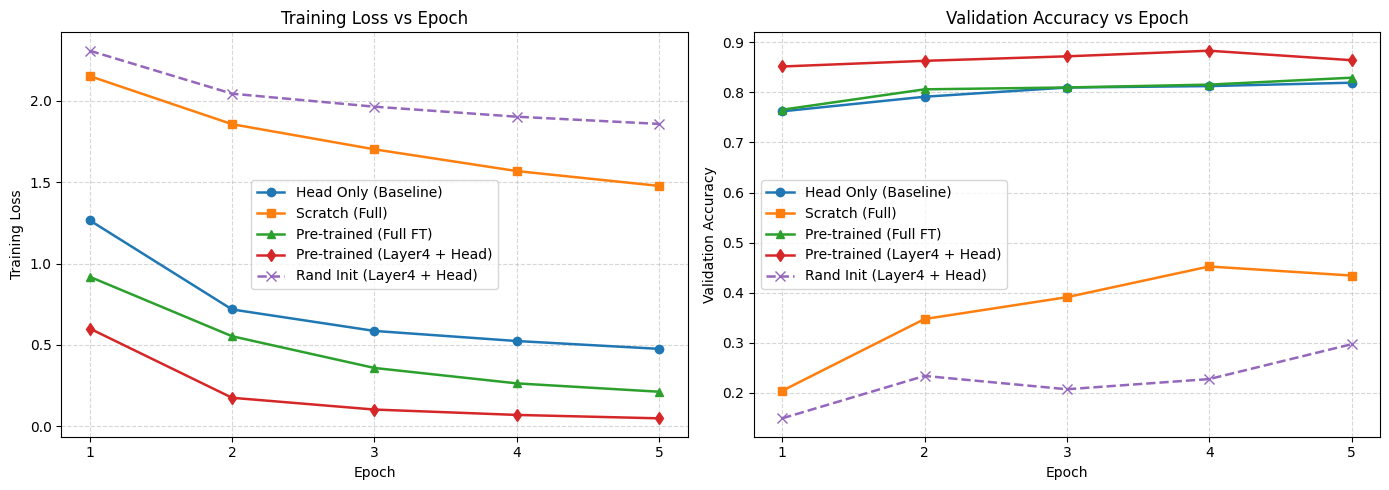

In [12]:
# ---------------------------------------------------------
# Plotting Comparison (Optimized for 5 Epochs)
# ---------------------------------------------------------
epochs_list = [h[0] for h in hist_scratch]

# Accuracy Lists
acc_base         = [h[2] for h in training_history]    # Head Only
acc_scratch      = [h[2] for h in hist_scratch]        # Scratch (Full)
acc_full         = [h[2] for h in hist_full_ft]        # Pre-trained (Full FT)
acc_partial      = [h[2] for h in hist_partial_ft]     # Pre-trained (Layer4 + Head)
acc_rand_partial = [h[2] for h in hist_random_partial] # Rand Init (Layer4 + Head)

# Loss Lists
loss_base         = [h[1] for h in training_history]
loss_scratch      = [h[1] for h in hist_scratch]
loss_full         = [h[1] for h in hist_full_ft]
loss_partial      = [h[1] for h in hist_partial_ft]
loss_rand_partial = [h[1] for h in hist_random_partial]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Common plot settings
line_kwargs = [
    {"label": "Head Only (Baseline)",             "marker": "o", "markersize": 6, "linewidth": 1.8},
    {"label": "Scratch (Full)",                   "marker": "s", "markersize": 6, "linewidth": 1.8},
    {"label": "Pre-trained (Full FT)",            "marker": "^", "markersize": 6, "linewidth": 1.8},
    {"label": "Pre-trained (Layer4 + Head)",      "marker": "d", "markersize": 6, "linewidth": 1.8},
    {"label": "Rand Init (Layer4 + Head)",        "marker": "x", "markersize": 7, "linewidth": 1.8, "linestyle": "--"},
]

# 1. Loss Curve
for loss, kw in zip([loss_base, loss_scratch, loss_full, loss_partial, loss_rand_partial], line_kwargs):
    axes[0].plot(epochs_list, loss, **kw)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss vs Epoch")
axes[0].set_xticks(epochs_list)
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# 2. Validation Accuracy Curve
for acc, kw in zip([acc_base, acc_scratch, acc_full, acc_partial, acc_rand_partial], line_kwargs):
    axes[1].plot(epochs_list, acc, **kw)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy vs Epoch")
axes[1].set_xticks(epochs_list)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_transfer_learning_comparison.png", dpi=200, bbox_inches="tight")
plt.show()